In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/processed/flights_day2.csv')
print(df.shape)

(5231130, 38)


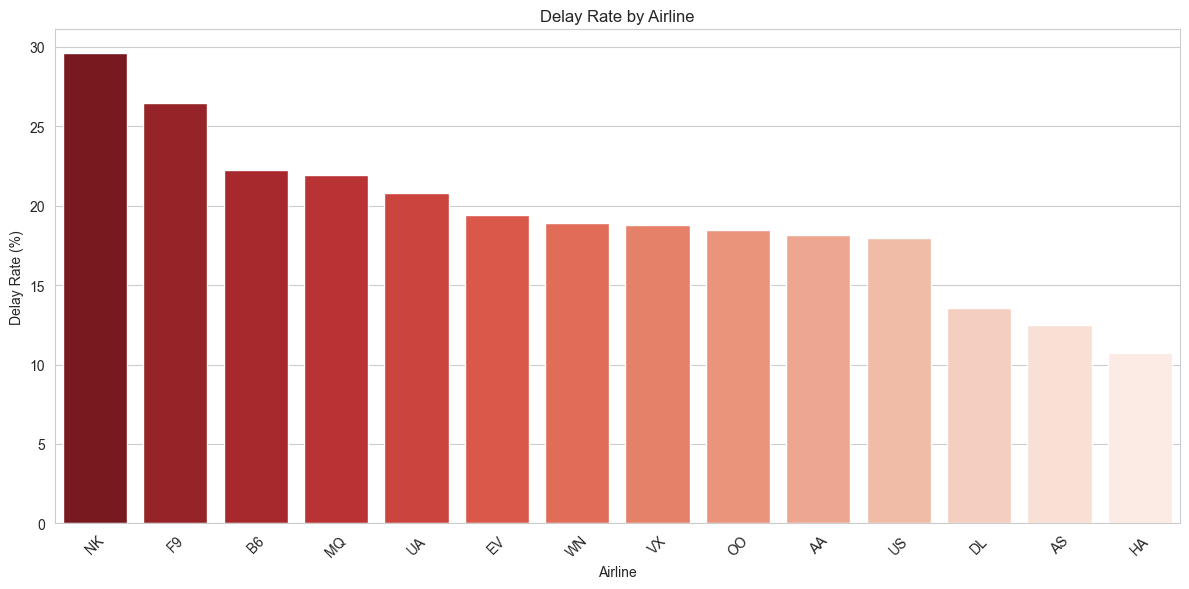

AIRLINE
NK    29.602414
F9    26.475215
B6    22.223933
MQ    21.946486
UA    20.789420
EV    19.412858
WN    18.928273
VX    18.807446
OO    18.457095
AA    18.151170
US    17.984482
DL    13.532675
AS    12.491641
HA    10.726921
Name: IS_DELAY, dtype: float64


In [3]:
airline_delay = df.groupby('AIRLINE')['IS_DELAY'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=airline_delay.index, y=airline_delay.values, hue=airline_delay.index, palette='Reds_r', legend=False)
plt.ylabel('Delay Rate (%)')
plt.xlabel('Airline')
plt.title('Delay Rate by Airline')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/airline_delay_rate.png', dpi=150)
plt.show()

print(airline_delay)

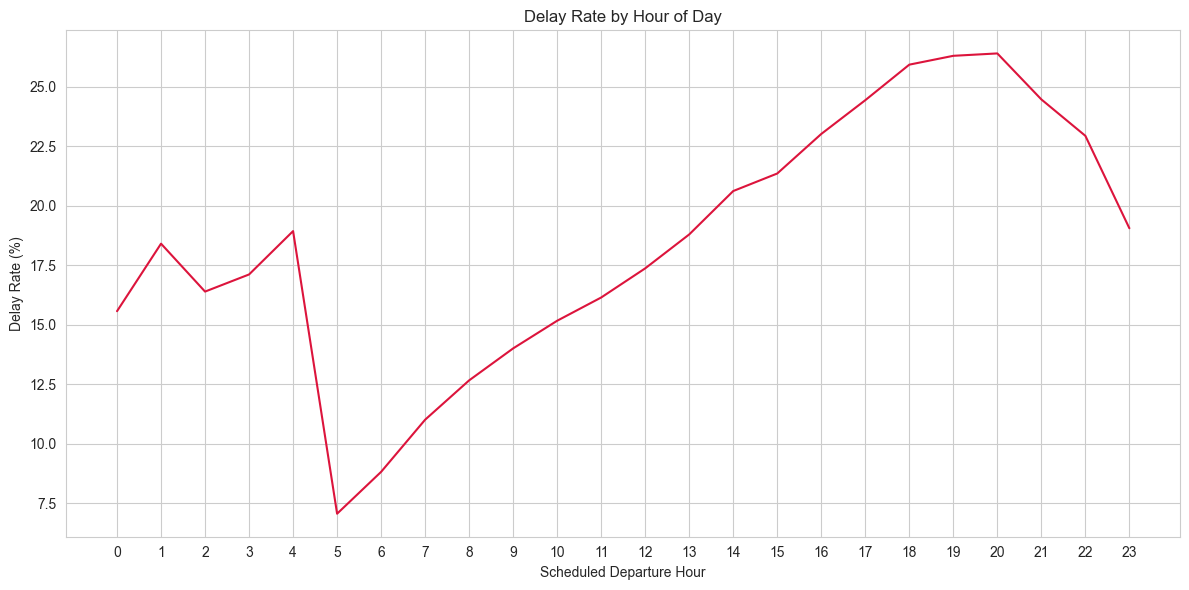

In [4]:
hour_delay = df.groupby('SCHED_DEP_HOUR')['IS_DELAY'].mean() * 100

plt.figure(figsize=(12, 6))
sns.lineplot(x=hour_delay.index, y=hour_delay.values, markers='o', color='crimson')
plt.ylabel('Delay Rate (%)')
plt.xlabel('Scheduled Departure Hour')
plt.title('Delay Rate by Hour of Day')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../reports/figures/hour_delay_rate.png', dpi=150)
plt.show()

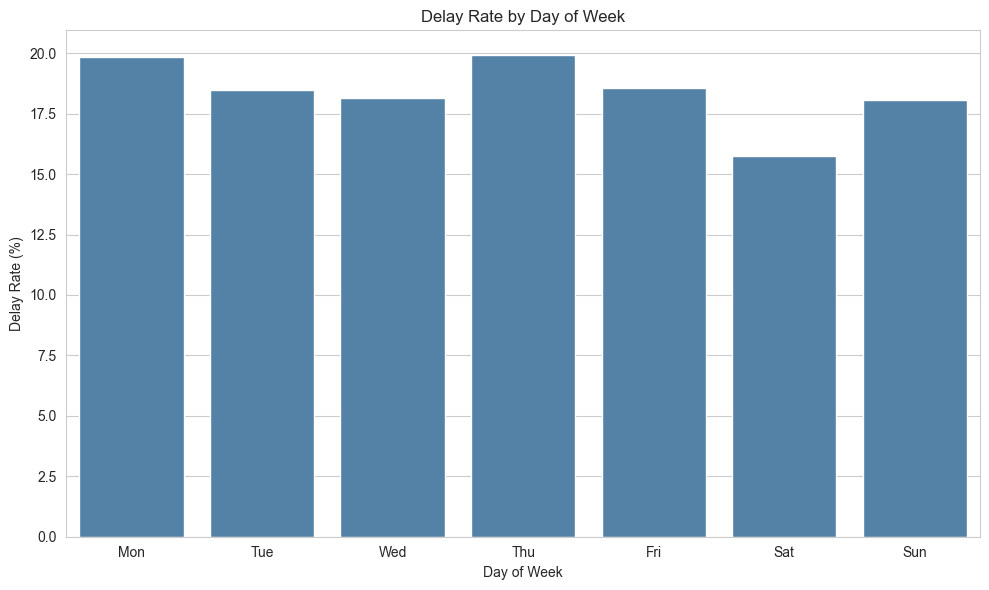

In [5]:
dow_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
dow_delay = df.groupby('DAY_OF_WEEK')['IS_DELAY'].mean() * 100
dow_delay.index = dow_delay.index.map(dow_map)

plt.figure(figsize=(10, 6))
sns.barplot(x=dow_delay.index, y=dow_delay.values, color='steelblue')
plt.ylabel('Delay Rate (%)')
plt.xlabel('Day of Week')
plt.title('Delay Rate by Day of Week')
plt.tight_layout()
plt.savefig('../reports/figures/dow_delay_rate.png', dpi=150)
plt.show()

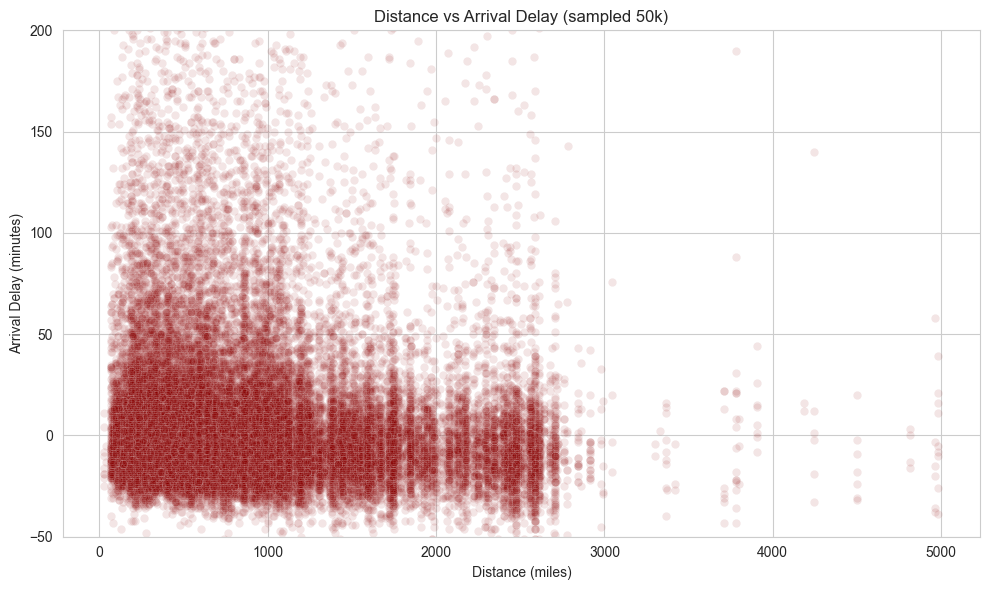

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(50000, random_state=42), x='DISTANCE', y='ARRIVAL_DELAY', alpha=0.1, color='darkred')
plt.ylim(-50, 200)
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')
plt.title('Distance vs Arrival Delay (sampled 50k)')
plt.tight_layout()
plt.savefig('../reports/figures/distance_vs_delay.png', dpi=150)
plt.show()

In [7]:
df.to_csv('../data/processed/flights_day3.csv', index=False)
print("Saved!", df.shape)

Saved! (5231130, 38)
